# 입력 feature 선택 및 Isolation Forest 모델 학습 및 검증

Updated ALLOW trial 기준으로 IsolationForest 를 `human inlier detector` 로 학습하고, 매크로 trial 을 outlier 로 판별하는 단일 실험 노트북입니다.

- 학습 데이터: `dataset_dir` 안의 ALLOW (human) trial
- 검증 데이터: 같은 디렉토리에 BLOCK (macro) trial 이 있으면 함께 검증, 없으면 ALLOW 분포의 quantile 로 threshold 결정
- 산출물: `runs/<run_name>/` 아래 model.joblib / meta.json / metrics.json / predictions.jsonl / report.md / **각종 PNG 시각화**

## 📌 성능 확인 / 조정 가이드

### ▶ 성능을 보려면
노트북 안 — **`## 5. 모델 검증`** 섹션의 ✅ 셀들이 핵심:
- `### 5.2 ALLOW / BLOCK score 분포 비교` — macro probability 요약 통계
- `### 5.3 분포 히스토그램` — 시각적 분리 가능성
- `### 5.4 threshold 결정 + validation metrics` — F1 / precision / recall / roc_auc
- `### 5.5 혼동 행렬` (텍스트), `### 5.12 confusion matrix heatmap` (시각화)
- `### 5.6 예측 결과 미리보기` — 오분류 trial 직접 확인
- `### 5.7 feature 간 상관관계 heatmap` — feature 중복성 점검
- `### 5.8 feature 별 ALLOW vs BLOCK boxplot` — feature 분리력
- `### 5.9 Threshold sweep`, `### 5.10 ROC curve`, `### 5.11 PR curve`

그리고 **`## 7. 결과 리포트`** — markdown + 전체 요약 JSON

### ▶ 디스크 산출물 (section 6)
- `services/ai/train/model_joblib/isolation_26_h1_v1_v3/model.joblib`
- `services/ai/train/model_joblib/isolation_26_h1_v1_v3/meta.json` (run_version, feature_names, dataset, params 포함)
- `services/ai/train/model_joblib/isolation_26_h1_v1_v3/metrics.json` (validation_metrics, score summary)

> 재실행 시 동일 위치에 덮어씀. 버전 식별은 meta.json 의 `run_version` 필드로.

### ▶ 성능을 조정하려면
주로 **`### 1.1 ⚙️ 학습 설정 (args)`** 셀.

| 항목 | 기본 | 의미 / 조정 효과 |
|---|---|---|
| `feature_mode` | "auto" | "auto"=데이터에서 numeric metric 키 자동 검출 / "file"=`features_path` JSON 사용 |
| `n_estimators` | 300 | 트리 수. ↑ → 안정성 ↑ (300→500/1000), 학습 시간 ↑ |
| `contamination` | 0.03 | 학습 데이터 중 이상치 추정 비율. ↑ → threshold 가 더 보수적 |
| `max_samples` | "auto" | 각 트리 학습 표본 수. "auto"=min(256, N) |
| `max_features` | 1.0 | 각 트리에서 사용할 feature 비율 (0.5~1.0) |
| `bootstrap` | False | True 면 각 트리가 중복허용 샘플링 |
| `random_state` | 42 | 재현성 시드 |
| `threshold_step` | 0.01 | threshold grid 정밀도 |
| `valid_ratio` | 0.2 | ALLOW 데이터의 train/valid 분할 비율 |

### ▶ 더 본질적인 개선
- **feature 선택**: cell-13-args 의 `DROP_FEATURES` 에 제거할 feature 추가, 또는 `feature_mode="file"` + `features_path` 수정
- **데이터 확보**: BLOCK trial 을 더 모아 `dataset_dir` 에 추가 → 자동으로 F1 기반 threshold 탐색 + 전체 시각화 활성화

## 1. 데이터 준비

In [1]:
from __future__ import annotations

import json
import re
from datetime import datetime
from pathlib import Path
from types import SimpleNamespace

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 노트북 위치 기반 경로
NOTEBOOK_DIR = Path.cwd()
AI_ROOT = NOTEBOOK_DIR.resolve().parents[1] if NOTEBOOK_DIR.name == "model_experiment" else Path("C:/Users/SSAFY/Desktop/ai-macro-detection/services/ai")

DEFAULT_FEATURES_PATH = AI_ROOT / "models" / "classifier" / "input_features.json"
DEFAULT_RUNS_DIR = AI_ROOT / "train" / "model_experiment" / "runs"
PATH_PATTERN_RE = re.compile(
    r"(?P<dist>[0-9]+(?:\.[0-9]+)?)px\s*\|\s*straight\s*(?P<straight>[0-9]+(?:\.[0-9]+)?)"
)
print("AI_ROOT:", AI_ROOT)

AI_ROOT: C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai


### 1.1 ⚙️ 학습 설정 (args)

성능을 조정하려면 이 셀의 값을 수정하세요. 위의 **성능 확인 / 조정 가이드** 표 참고.

In [2]:
# ============================================================
# VERSION HISTORY  (활성 버전 1개만 uncomment)
# ============================================================
#
# 데이터셋과 실험 버전 구분
# ------------------------------------------------------------
# - data_h1_v1_allow : 실제 학습용 ALLOW 데이터셋
# - data_m1_v2_block: 외부 테스트용 BLOCK 데이터셋
#
# - v3, v4, v5, v6 ... 은 데이터셋 이름이 아니라 실험 버전 이름
# - v4 데이터라는 별도 폴더/파일은 없음
# - v4_clean_count13은 data_h1_v1_allow에서 count=13 trial만 제거하는 중간 실험 후보
# - 실제 비교는 v3_baseline_27 vs v5_clean_count13_time_strict 중심으로 진행
#
# ------------------------------------------------------------
# 공통 feature 조건
# ------------------------------------------------------------
# - trial_00720은 원본 데이터에서 이미 제거 완료
# - 현재 auto-detected feature 수: 27
# - DROP_FEATURES는 현재 적용하지 않음
# - count=24 trial은 click 1회로 인한 자연 결측 가능성이 높아 유지
# - count=13 trial은 mouse/click 통계 대량 결측으로 제거 후보
#
# ============================================================
# v3_baseline_27
# ------------------------------------------------------------
# 목적:
# - 720 제거 후 남은 data_h1_v1_allow 전체를 사용하는 baseline
#
# 학습 데이터:
# - data_h1_v1_allow
# - ALLOW 719개
#
# 정제 조건:
# - DROP_FEATURES 없음
# - MIN_NUMERIC_FEATURE_COUNT 없음
# - EXCLUDE_TRIAL_IDS 없음
#
# 결과 요약:
# - test_data: data_m1_v2_block
# - test BLOCK: 460개
# - caught BLOCK: 150개
# - recall: 32.61%
# - fold p95 std/mean: 35.29%
# - human_valid: 144개
# - human_valid FP: 약 5개
#
# RUN_VERSION = "v3_baseline_27"
# DROP_FEATURES = []
# MIN_NUMERIC_FEATURE_COUNT = None
# EXCLUDE_TRIAL_IDS = []
#
# FEATURE_MODE = "auto"
# FEATURES_PATH = str(DEFAULT_FEATURES_PATH)
# N_ESTIMATORS = 300
# CONTAMINATION = 0.03
# MAX_SAMPLES = "auto"
# MAX_FEATURES = 1.0
# BOOTSTRAP = False
# THRESHOLD_STEP = 0.01
#
# ============================================================
# v4_clean_count13
# ------------------------------------------------------------
# 목적:
# - numeric_count가 낮은 count=13 trial만 제거했을 때 효과 확인
# - 실제로 별도 실행하지 않은 중간 실험 후보
#
# 학습 데이터:
# - data_h1_v1_allow
# - 예상 ALLOW: 719 - 14 = 705개
#
# 정제 조건:
# - DROP_FEATURES 없음
# - MIN_NUMERIC_FEATURE_COUNT = 14
# - EXCLUDE_TRIAL_IDS 없음
#
# 해석:
# - count=13 trial은 제거하지만 시간 이상 trial은 유지
# - v3와 v5 사이의 중간 비교 후보
# - 현재는 결과 없음
#
# RUN_VERSION = "v4_clean_count13"
# DROP_FEATURES = []
# MIN_NUMERIC_FEATURE_COUNT = 14
# EXCLUDE_TRIAL_IDS = []
#
# FEATURE_MODE = "auto"
# FEATURES_PATH = str(DEFAULT_FEATURES_PATH)
# N_ESTIMATORS = 300
# CONTAMINATION = 0.03
# MAX_SAMPLES = "auto"
# MAX_FEATURES = 1.0
# BOOTSTRAP = False
# THRESHOLD_STEP = 0.01
#
# ============================================================
# v5_clean_count13_time_strict
# ------------------------------------------------------------
# 목적:
# - EDA 기반 데이터 정제 효과 확인
# - count=13 trial 제거 + 시간 기반 이상 trial 제거
# - 현재 기준 baseline
#
# 학습 데이터:
# - data_h1_v1_allow
# - ALLOW 719개
# - 시간 이상 trial 5개 제거 → 714개
# - count=13 trial 14개 제거 → 700개
#
# 정제 조건:
# - DROP_FEATURES 없음
# - MIN_NUMERIC_FEATURE_COUNT = 14
# - EXCLUDE_TRIAL_IDS = [339, 369, 383, 721, 750]
#
# 시간 이상 trial 제거 기준:
# - time_to_first_click_ms > 300,000ms 수준
# - 또는 inter_click_interval_ms > 180,000ms 수준
# - 수집 중 방치/중단/재개 가능성이 높은 trial 제거
#
# 결과 요약:
# - test_data: data_m1_v2_block
# - test BLOCK: 460개
# - caught BLOCK: 222개
# - recall: 48.26%
# - fold p95 std/mean: 11.24%
# - human_valid: 140개
# - human_valid FP: 5개
#
# 비교 요약:
# - v3 대비 caught BLOCK: 150 → 222, +72
# - v3 대비 recall: 32.61% → 48.26%, +15.65%p
# - v3 대비 fold p95 std/mean: 35.29% → 11.24%, -24.05%p
#
RUN_VERSION = "v5_clean_count13_time_strict"
DROP_FEATURES = []
MIN_NUMERIC_FEATURE_COUNT = 14
EXCLUDE_TRIAL_IDS = [339, 369, 383, 721, 750]

FEATURE_MODE = "auto"
FEATURES_PATH = str(DEFAULT_FEATURES_PATH)
N_ESTIMATORS = 300
CONTAMINATION = 0.03
MAX_SAMPLES = "auto"
MAX_FEATURES = 1.0
BOOTSTRAP = False
THRESHOLD_STEP = 0.01
#
# ============================================================
# v6_clean_count13_time_strict_max_features_07
# ------------------------------------------------------------
# 목적:
# - v5 정제 조건 고정
# - max_features 1.0 → 0.7 조정
# - 일부 feature 조합에 대한 과의존 완화 여부 확인
#
# 학습 데이터:
# - v5와 동일
# - 예상 ALLOW: 700개
#
# 정제 조건:
# - DROP_FEATURES 없음
# - MIN_NUMERIC_FEATURE_COUNT = 14
# - EXCLUDE_TRIAL_IDS = [339, 369, 383, 721, 750]
#
# 하이퍼파라미터 변경:
# - MAX_FEATURES = 0.7
#
# 비교 기준:
# - v5 recall 48.26%보다 상승하는지
# - fold p95 std/mean이 20% 이하로 유지되는지
# - human_valid FP가 5개 근처로 유지되는지
#
# RUN_VERSION = "v6_clean_count13_time_strict_max_features_07"
# DROP_FEATURES = []
# MIN_NUMERIC_FEATURE_COUNT = 14
# EXCLUDE_TRIAL_IDS = [339, 369, 383, 721, 750]
#
# FEATURE_MODE = "auto"
# FEATURES_PATH = str(DEFAULT_FEATURES_PATH)
# N_ESTIMATORS = 300
# CONTAMINATION = 0.03
# MAX_SAMPLES = "auto"
# MAX_FEATURES = 0.7
# BOOTSTRAP = False
# THRESHOLD_STEP = 0.01
#
# ============================================================
# v7_clean_count13_time_strict_max_features_05
# ------------------------------------------------------------
# 목적:
# - v5 정제 조건 고정
# - max_features 1.0 → 0.5 조정
# - 더 강한 feature subsampling 효과 확인
#
# 학습 데이터:
# - v5와 동일
# - 예상 ALLOW: 700개
#
# 하이퍼파라미터 변경:
# - MAX_FEATURES = 0.5
#
# 비교 기준:
# - v5/v6 대비 recall 상승 여부
# - fold 안정성이 유지되는지
# - human_valid FP가 과도하게 증가하지 않는지
#
# RUN_VERSION = "v7_clean_count13_time_strict_max_features_05"
# DROP_FEATURES = []
# MIN_NUMERIC_FEATURE_COUNT = 14
# EXCLUDE_TRIAL_IDS = [339, 369, 383, 721, 750]
#
# FEATURE_MODE = "auto"
# FEATURES_PATH = str(DEFAULT_FEATURES_PATH)
# N_ESTIMATORS = 300
# CONTAMINATION = 0.03
# MAX_SAMPLES = "auto"
# MAX_FEATURES = 0.5
# BOOTSTRAP = False
# THRESHOLD_STEP = 0.01
#
# ============================================================
# v8_clean_count13_time_strict_max_features_07_contamination_05
# ------------------------------------------------------------
# 목적:
# - v6 기준에서 contamination 0.03 → 0.05 조정
# - BLOCK recall 상승 여부 확인
#
# 학습 데이터:
# - v5와 동일
# - 예상 ALLOW: 700개
#
# 하이퍼파라미터 변경:
# - MAX_FEATURES = 0.7
# - CONTAMINATION = 0.05
#
# 주의:
# - recall은 상승할 수 있음
# - human_valid FP도 함께 증가할 수 있음
#
# RUN_VERSION = "v8_clean_count13_time_strict_max_features_07_contamination_05"
# DROP_FEATURES = []
# MIN_NUMERIC_FEATURE_COUNT = 14
# EXCLUDE_TRIAL_IDS = [339, 369, 383, 721, 750]
#
# FEATURE_MODE = "auto"
# FEATURES_PATH = str(DEFAULT_FEATURES_PATH)
# N_ESTIMATORS = 300
# CONTAMINATION = 0.05
# MAX_SAMPLES = "auto"
# MAX_FEATURES = 0.7
# BOOTSTRAP = False
# THRESHOLD_STEP = 0.01
#
# ============================================================

args = SimpleNamespace(
    # 데이터
    dataset_dir=str(AI_ROOT / "data" / "data_h1_v1_allow"),
    valid_ratio=0.2,
    glob="**/trial_*.json",
    run_name=f"iforest_{RUN_VERSION}",

    # feature 소스
    feature_mode=FEATURE_MODE,
    features_path=FEATURES_PATH,

    # 모델 하이퍼파라미터
    n_estimators=N_ESTIMATORS,
    contamination=CONTAMINATION,
    max_samples=MAX_SAMPLES,
    max_features=MAX_FEATURES,
    bootstrap=BOOTSTRAP,
    random_state=42,

    # 검증
    threshold_step=THRESHOLD_STEP,
)

print("RUN_VERSION              :", RUN_VERSION)
print("DROP_FEATURES            :", DROP_FEATURES)
print("MIN_NUMERIC_FEATURE_COUNT:", MIN_NUMERIC_FEATURE_COUNT)
print("EXCLUDE_TRIAL_IDS        :", EXCLUDE_TRIAL_IDS)
print("dataset_dir              :", args.dataset_dir)
print("feature_mode             :", args.feature_mode)
print("features_path            :", args.features_path)
print("n_estimators             :", args.n_estimators)
print("contamination            :", args.contamination)
print("max_samples              :", args.max_samples)
print("max_features             :", args.max_features)
print("bootstrap                :", args.bootstrap)
print("threshold_step           :", args.threshold_step)


RUN_VERSION              : v5_clean_count13_time_strict
DROP_FEATURES            : []
MIN_NUMERIC_FEATURE_COUNT: 14
EXCLUDE_TRIAL_IDS        : [339, 369, 383, 721, 750]
dataset_dir              : C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow
feature_mode             : auto
features_path            : C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\models\classifier\input_features.json
n_estimators             : 300
contamination            : 0.03
max_samples              : auto
max_features             : 1.0
bootstrap                : False
threshold_step           : 0.01


### 1.2 데이터 로드 헬퍼 함수

각 trial JSON 의 `metrics` 필드에서 feature 를 뽑아 DataFrame 으로 만드는 유틸. label 별로 자동 분리합니다.

In [3]:
def load_feature_names(path):
    feature_path = Path(path).expanduser().resolve()
    payload = json.loads(feature_path.read_text(encoding="utf-8-sig"))
    if not isinstance(payload, list) or not payload:
        raise ValueError(f"feature file must be a non-empty json list: {feature_path}")
    return [str(value) for value in payload]


def parse_mouse_path_pattern(value):
    if not isinstance(value, str):
        return (float("nan"), float("nan"))
    match = PATH_PATTERN_RE.search(value.strip())
    if not match:
        return (float("nan"), float("nan"))
    return (float(match.group("dist")), float(match.group("straight")))


def to_float_or_nan(value):
    if value is None:
        return float("nan")
    if isinstance(value, bool):
        return float(int(value))
    if isinstance(value, (int, float)):
        return float(value)
    try:
        return float(value)
    except Exception:
        return float("nan")


def extract_feature_row(feature_map, feature_names):
    # 구형 데이터셋은 pre_click_mouse_path_pattern_300ms / _500ms 문자열을 넣고,
    # allow 데이터셋은 파생 4개 feature 를 numeric 으로 직접 넣는다.
    distance_300, straight_300 = parse_mouse_path_pattern(feature_map.get("pre_click_mouse_path_pattern_300ms"))
    distance_500, straight_500 = parse_mouse_path_pattern(feature_map.get("pre_click_mouse_path_pattern_500ms"))
    derived = {
        "pre_click_path_300ms_total_distance_px": distance_300,
        "pre_click_path_300ms_straightness": straight_300,
        "pre_click_path_500ms_total_distance_px": distance_500,
        "pre_click_path_500ms_straightness": straight_500,
    }

    row = {}
    for feature_name in feature_names:
        raw = feature_map.get(feature_name)
        if raw is not None:
            row[feature_name] = to_float_or_nan(raw)
        elif feature_name in derived:
            row[feature_name] = float(derived[feature_name])
        else:
            row[feature_name] = float("nan")
    return row


def iter_trial_paths(data_dir, pattern):
    if isinstance(data_dir, (list, tuple)):
        all_paths = []
        for d in data_dir:
            all_paths.extend(iter_trial_paths(d, pattern))
        return all_paths
    root = Path(data_dir).expanduser().resolve()
    if not root.exists():
        raise FileNotFoundError(f"dataset path not found: {root}")
    if root.is_file():
        return [root]
    return sorted(path for path in root.glob(pattern) if path.is_file())


def _load_trial_json(path):
    try:
        return json.loads(path.read_text(encoding="utf-8-sig"))
    except (json.JSONDecodeError, UnicodeDecodeError) as e:
        print(f"  ! skip {path.name}: {e}")
        return None


def get_feature_map(trial):
    if not isinstance(trial, dict):
        return None
    feature_map = trial.get("metrics")
    if isinstance(feature_map, dict):
        return feature_map
    feature_map = trial.get("features")
    if isinstance(feature_map, dict):
        return feature_map
    return None


def discover_feature_names(data_dir, pattern):
    numeric_with_value = set()
    string_only_keys = set()

    for path in iter_trial_paths(data_dir, pattern):
        trial = _load_trial_json(path)
        feature_map = get_feature_map(trial)
        if not isinstance(feature_map, dict):
            continue
        for k, v in feature_map.items():
            if v is None:
                continue
            if isinstance(v, bool) or isinstance(v, (int, float)):
                numeric_with_value.add(k)
                continue
            try:
                float(v)
                numeric_with_value.add(k)
            except (TypeError, ValueError):
                string_only_keys.add(k)

    if string_only_keys & {"pre_click_mouse_path_pattern_300ms", "pre_click_mouse_path_pattern_500ms"}:
        for f in (
            "pre_click_path_300ms_total_distance_px",
            "pre_click_path_300ms_straightness",
            "pre_click_path_500ms_total_distance_px",
            "pre_click_path_500ms_straightness",
        ):
            numeric_with_value.add(f)

    return sorted(numeric_with_value), sorted(string_only_keys)


def load_trials_by_label(data_dir, feature_names, pattern):
    rows_by_label = {}
    for path in iter_trial_paths(data_dir, pattern):
        trial = _load_trial_json(path)
        if not isinstance(trial, dict):
            continue
        label = trial.get("label")
        if label is None:
            summary = trial.get("summary")
            if isinstance(summary, dict):
                label = summary.get("label")
        if label is None:
            continue
        label = str(label)
        feature_map = get_feature_map(trial)
        if not isinstance(feature_map, dict):
            continue
        row = {
            "trial_id": trial.get("trialID", trial.get("trialId", trial.get("trial_id"))),
            "label": label,
            "path": str(path),
        }
        row.update(extract_feature_row(feature_map, feature_names))
        rows_by_label.setdefault(label, []).append(row)
    if not rows_by_label:
        raise RuntimeError(f"no usable trials found in {data_dir}")
    return {label: pd.DataFrame(rows) for label, rows in rows_by_label.items()}


### 1.3 데이터 로드 실행 ✅

`dataset_dir` 의 모든 trial 을 읽고 label 별 카운트를 출력합니다.

In [4]:
if args.feature_mode == "auto":
    feature_names, skipped_keys = discover_feature_names(args.dataset_dir, args.glob)
    print(f"feature_mode=auto: {len(feature_names)} 개 numeric feature 자동 검출")
    if skipped_keys:
        print(f"  - 문자열-only 키 {len(skipped_keys)} 개 제외: {skipped_keys}")
elif args.feature_mode == "file":
    feature_names = load_feature_names(args.features_path)
    skipped_keys = []
    print(f"feature_mode=file: {args.features_path} 에서 {len(feature_names)} 개 로드")
else:
    raise ValueError(f"unknown feature_mode: {args.feature_mode!r} (use 'auto' or 'file')")

# DROP_FEATURES 적용 — cell-13 활성 버전의 제거 리스트
if DROP_FEATURES:
    before = len(feature_names)
    feature_names = [f for f in feature_names if f not in DROP_FEATURES]
    print(f"\nDROP_FEATURES 적용: -{before - len(feature_names)} → 최종 {len(feature_names)} 개")

trials_by_label = load_trials_by_label(args.dataset_dir, feature_names, args.glob)

print()
print("feature 목록:")
for f in feature_names:
    print(f"  - {f}")
print()
print("label 별 trial 수 :")
for label, df in trials_by_label.items():
    print(f"  {label}: {len(df)}")


feature_mode=auto: 27 개 numeric feature 자동 검출

feature 목록:
  - click_position_repeat_rate
  - click_sequence_consistency_score
  - double_click_rate
  - edge_or_fixed_point_visit_rate
  - inter_click_interval_ms
  - misclick_rate
  - mouse_acceleration_mean
  - mouse_avg_speed_px_per_ms
  - mouse_direction_change_count
  - mouse_jerk_mean
  - mouse_max_speed_px_per_ms
  - mouse_overshoot_flag
  - mouse_path_curvature_mean
  - mouse_path_straightness_score
  - mouse_speed_change_mean
  - mouse_stop_segment_count
  - mouse_total_travel_distance_px
  - mousemove_event_rate
  - pre_click_hover_time_ms
  - pre_click_mousemove_count
  - pre_click_path_300ms_straightness
  - pre_click_path_300ms_total_distance_px
  - pre_click_path_500ms_straightness
  - pre_click_path_500ms_total_distance_px
  - pre_click_scroll_flag
  - reclick_rate
  - time_to_first_click_ms

label 별 trial 수 :
  ALLOW: 719


## 2. 데이터 전처리

### 2.1 ALLOW / BLOCK 분리 및 train / valid 분할

- ALLOW (human) 은 `valid_ratio` 비율로 train/valid split
- BLOCK (macro) 은 전부 macro_valid 로 사용
- BLOCK 이 없으면 `has_macro=False` 로 진행

In [5]:
if "ALLOW" not in trials_by_label:
    raise RuntimeError(f"no ALLOW trials found in {args.dataset_dir}")

human_all = trials_by_label["ALLOW"].reset_index(drop=True)

# ------------------------------------------------------------
# 1. EXCLUDE_TRIAL_IDS 적용
# - EDA에서 확인한 시간 기반 이상 trial 제거
# ------------------------------------------------------------
if EXCLUDE_TRIAL_IDS:
    before = len(human_all)

    exclude_as_str = {str(x) for x in EXCLUDE_TRIAL_IDS}

    human_all = human_all[
        ~human_all["trial_id"].astype(str).isin(exclude_as_str)
    ].reset_index(drop=True)

    removed_count = before - len(human_all)

    print(
        f"EXCLUDE_TRIAL_IDS 적용: "
        f"-{removed_count} → human_all {len(human_all)}"
    )
    print("제거 대상:", EXCLUDE_TRIAL_IDS)
    print()
else:
    print("EXCLUDE_TRIAL_IDS 미적용")
    print()

# ------------------------------------------------------------
# 2. MIN_NUMERIC_FEATURE_COUNT 적용
# - numeric feature count가 기준보다 낮은 trial 제거
# - v5에서는 14로 설정하여 count=13 trial 제거
# ------------------------------------------------------------
if MIN_NUMERIC_FEATURE_COUNT is not None:
    before = len(human_all)

    numeric_cols = [
        col for col in feature_names
        if col in human_all.columns
    ]

    numeric_count = human_all[numeric_cols].notna().sum(axis=1)

    removed_mask = numeric_count < MIN_NUMERIC_FEATURE_COUNT
    removed_df = human_all[removed_mask].copy()
    removed_numeric_count = numeric_count[removed_mask].copy()

    human_all = human_all[~removed_mask].reset_index(drop=True)

    removed_count = before - len(human_all)

    print(
        f"MIN_NUMERIC_FEATURE_COUNT 적용: "
        f"{MIN_NUMERIC_FEATURE_COUNT}개 미만 제거 -{removed_count} → human_all {len(human_all)}"
    )

    if removed_count > 0:
        removed_preview = pd.DataFrame({
            "trial_id": removed_df["trial_id"].values,
            "numeric_count": removed_numeric_count.values,
        })

        print("제거된 trial:")
        display(removed_preview)

    print()
else:
    print("MIN_NUMERIC_FEATURE_COUNT 미적용")
    print()

macro_valid = trials_by_label.get(
    "BLOCK",
    pd.DataFrame(columns=human_all.columns),
).reset_index(drop=True)

has_macro = len(macro_valid) > 0

human_train, human_valid = train_test_split(
    human_all,
    test_size=args.valid_ratio,
    random_state=args.random_state,
    shuffle=True,
)

human_train = human_train.reset_index(drop=True)
human_valid = human_valid.reset_index(drop=True)

print(f"human_total : {len(human_all)}")
print(f"human_train : {len(human_train)}")
print(f"human_valid : {len(human_valid)}")
print(f"macro_valid : {len(macro_valid)}  (has_macro={has_macro})")

EXCLUDE_TRIAL_IDS 적용: -5 → human_all 714
제거 대상: [339, 369, 383, 721, 750]

MIN_NUMERIC_FEATURE_COUNT 적용: 14개 미만 제거 -14 → human_all 700
제거된 trial:


,trial_id,numeric_count
0,195,13
1,206,13
2,333,13
3,366,13
4,371,13
5,374,13
6,377,13
7,491,13
8,568,13
9,576,13



human_total : 700
human_train : 560
human_valid : 140
macro_valid : 0  (has_macro=False)


### 2.2 ✅ 결측치 점검

feature 별 NaN 비율을 확인합니다. 100% NaN feature 는 모델 학습 시 SimpleImputer 가 건너뛰므로 사실상 무력화됩니다.

In [6]:
nan_ratio = human_train[feature_names].isna().mean().sort_values(ascending=False)
print("human_train NaN 비율 (높은 순):")
print(nan_ratio.to_string())

human_train NaN 비율 (높은 순):
click_position_repeat_rate                0.278571
click_sequence_consistency_score          0.278571
inter_click_interval_ms                   0.278571
mouse_jerk_mean                           0.037500
mouse_acceleration_mean                   0.005357
mouse_speed_change_mean                   0.005357
mouse_path_curvature_mean                 0.005357
misclick_rate                             0.000000
mouse_avg_speed_px_per_ms                 0.000000
double_click_rate                         0.000000
edge_or_fixed_point_visit_rate            0.000000
mouse_max_speed_px_per_ms                 0.000000
mouse_direction_change_count              0.000000
mouse_overshoot_flag                      0.000000
mouse_path_straightness_score             0.000000
mouse_stop_segment_count                  0.000000
mouse_total_travel_distance_px            0.000000
mousemove_event_rate                      0.000000
pre_click_hover_time_ms                   0.000000
pre_

## 3. 모델 준비

Pipeline: `SimpleImputer(median, add_indicator=True)` → `IsolationForest(...)`. 
hyperparameter 는 위 `args` 셀에서 조정합니다.

In [7]:
def parse_max_samples(raw):
    value = str(raw).strip()
    if value == "auto":
        return value
    if "." in value:
        return float(value)
    return int(value)


def make_model(args):
    from sklearn.ensemble import IsolationForest
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import Pipeline

    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            (
                "iforest",
                IsolationForest(
                    n_estimators=args.n_estimators,
                    contamination=args.contamination,
                    max_samples=parse_max_samples(args.max_samples),
                    max_features=args.max_features,
                    bootstrap=bool(args.bootstrap),
                    random_state=args.random_state,
                ),
            ),
        ]
    )


model = make_model(args)
model

,steps,"[('imputer', ...), ('iforest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,True
,keep_empty_features,False
,n_estimators,300


## 4. 모델 학습

human_train 만으로 fit. macro 데이터는 학습에 사용하지 않습니다.

In [8]:
model.fit(human_train[feature_names])
print("학습 완료. 학습 표본 수:", len(human_train))

학습 완료. 학습 표본 수: 560


### 4.1 ✅ 학습 데이터 score 분포 확인

학습 데이터의 raw decision_function 분포. inlier 일수록 큰 값. 분포가 너무 좁거나 NaN-only feature 만 남아 점수가 거의 균일하면 학습 의미 X.

In [9]:
train_raw_scores = np.asarray(model.decision_function(human_train[feature_names]), dtype=np.float64)
print(pd.Series(train_raw_scores).describe().to_string())

count    560.000000
mean       0.109749
std        0.048722
min       -0.115572
25%        0.088891
50%        0.117452
75%        0.147661
max        0.180034


## 5. 모델 검증

**🎯 여기가 성능 확인의 핵심 섹션입니다.** 
각 ✅ 셀은 figure 를 `figures` dict 에 누적하고, section 6 에서 PNG 로 일괄 저장됩니다.

### 5.1 score 변환 / 평가 함수

IsolationForest 의 `decision_function` 은 inlier 일수록 큰 값을 반환합니다. center/scale 로 표준화 후 sigmoid 로 flip 하여 **macro probability** 로 매핑합니다.

In [10]:
def sigmoid(values):
    clipped = np.clip(values, -60.0, 60.0)
    return 1.0 / (1.0 + np.exp(-clipped))


def decision_scores_to_macro_probability(raw_scores, center, scale):
    safe_scale = max(scale, 1e-6)
    return sigmoid((center - raw_scores) / safe_scale)


def summarize_scores(values):
    if len(values) == 0:
        return {"count": 0}
    return {
        "count": int(len(values)),
        "min": float(np.min(values)),
        "p05": float(np.quantile(values, 0.05)),
        "p25": float(np.quantile(values, 0.25)),
        "p50": float(np.quantile(values, 0.50)),
        "p75": float(np.quantile(values, 0.75)),
        "p95": float(np.quantile(values, 0.95)),
        "max": float(np.max(values)),
        "mean": float(np.mean(values)),
        "std": float(np.std(values)),
    }


def choose_best_threshold(y_true, y_score, step):
    best = None
    for threshold in np.arange(step, 1.0, step):
        y_pred = (y_score >= threshold).astype(int)
        tn = int(np.sum((y_true == 0) & (y_pred == 0)))
        fp = int(np.sum((y_true == 0) & (y_pred == 1)))
        fn = int(np.sum((y_true == 1) & (y_pred == 0)))
        tp = int(np.sum((y_true == 1) & (y_pred == 1)))
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2.0 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        current = {
            "threshold": float(threshold),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        }
        if best is None or (current["f1"], current["recall"], -current["fp"]) > (
            best["f1"], best["recall"], -best["fp"],
        ):
            best = current
    if best is None:
        raise RuntimeError("failed to choose threshold")
    return best


def evaluate_scores(y_true, y_score, threshold):
    from sklearn.metrics import (
        accuracy_score, average_precision_score, confusion_matrix,
        f1_score, precision_score, recall_score, roc_auc_score,
    )
    y_pred = (y_score >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_score)),
        "average_precision": float(average_precision_score(y_true, y_score)),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist(),
    }

### 5.2 ✅ ALLOW / BLOCK score 분포 비교

valid set 의 decision_function → macro probability 변환. ALLOW 의 분포가 낮고 BLOCK 의 분포가 높을수록 분리가 잘 된 모델.

In [11]:
human_raw_scores = np.asarray(model.decision_function(human_valid[feature_names]), dtype=np.float64)
center = float(np.quantile(human_raw_scores, args.contamination))
scale = float(np.std(human_raw_scores))
if not np.isfinite(scale) or scale <= 1e-6:
    scale = 0.05

human_macro_prob = decision_scores_to_macro_probability(human_raw_scores, center=center, scale=scale)

if has_macro:
    macro_raw_scores = np.asarray(model.decision_function(macro_valid[feature_names]), dtype=np.float64)
    macro_macro_prob = decision_scores_to_macro_probability(macro_raw_scores, center=center, scale=scale)
else:
    macro_raw_scores = np.array([], dtype=np.float64)
    macro_macro_prob = np.array([], dtype=np.float64)

print(f"score_center : {center:.6f}")
print(f"score_scale  : {scale:.6f}")
print()
print("ALLOW (human_valid) macro_prob 분포 :")
print(json.dumps(summarize_scores(human_macro_prob), indent=2))
print()
print("BLOCK (macro_valid) macro_prob 분포 :")
print(json.dumps(summarize_scores(macro_macro_prob), indent=2))

score_center : 0.029841
score_scale  : 0.038531

ALLOW (human_valid) macro_prob 분포 :
{
  "count": 140,
  "min": 0.020808208404287713,
  "p05": 0.02876119027339299,
  "p25": 0.051410862950277074,
  "p50": 0.08551249749620407,
  "p75": 0.17056545437061787,
  "p95": 0.41462886228931334,
  "max": 0.6170815841690814,
  "mean": 0.1360247613651609,
  "std": 0.13196978311728375
}

BLOCK (macro_valid) macro_prob 분포 :
{
  "count": 0
}


### 5.3 ✅ macro probability 분포 히스토그램

ALLOW(파랑) 와 BLOCK(빨강) 의 macro probability 분포를 시각화. 두 분포가 겹치는 영역이 적을수록 분리가 잘 되는 모델.

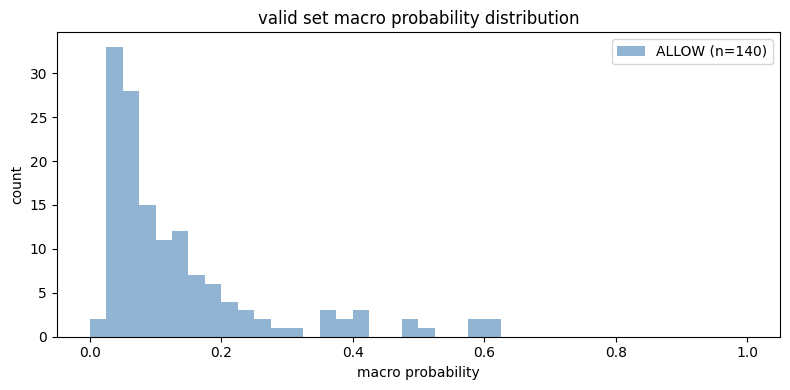

In [12]:
figures = {}  # 이후 viz 셀에서 누적, section 6 에서 PNG 로 저장

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0.0, 1.0, 41)
ax.hist(human_macro_prob, bins=bins, alpha=0.6, label=f"ALLOW (n={len(human_macro_prob)})", color="steelblue")
if has_macro:
    ax.hist(macro_macro_prob, bins=bins, alpha=0.6, label=f"BLOCK (n={len(macro_macro_prob)})", color="indianred")
ax.set_xlabel("macro probability")
ax.set_ylabel("count")
ax.set_title("valid set macro probability distribution")
ax.legend()
plt.tight_layout()
figures["score_histogram"] = fig
plt.show()

### 5.4 ✅ threshold 결정 + validation metrics

- **BLOCK 데이터가 있으면**: F1 최대화 (tie-break: recall ↑, fp ↓) 로 best threshold 탐색 + precision / recall / f1 / roc_auc / average_precision 계산
- **BLOCK 데이터가 없으면**: ALLOW probability 의 `1 - contamination` quantile 로 threshold 결정 (validation metric 없음)

In [13]:
if has_macro:
    y_true = np.concatenate([
        np.zeros(len(human_macro_prob), dtype=int),
        np.ones(len(macro_macro_prob), dtype=int),
    ])
    y_score = np.concatenate([human_macro_prob, macro_macro_prob])
    best_threshold = choose_best_threshold(y_true, y_score, args.threshold_step)
    validation_metrics = evaluate_scores(y_true, y_score, threshold=float(best_threshold["threshold"]))
else:
    y_true = np.zeros(len(human_macro_prob), dtype=int)
    y_score = human_macro_prob.copy()
    threshold = float(np.quantile(human_macro_prob, 1.0 - args.contamination))
    best_threshold = {
        "threshold": threshold,
        "precision": None, "recall": None, "f1": None,
        "strategy": "quantile_of_human_only",
    }
    validation_metrics = None

print("best_threshold :")
print(json.dumps(best_threshold, indent=2))
print()
print("validation_metrics :")
print(json.dumps(validation_metrics, indent=2) if validation_metrics else "  (no BLOCK data — skipped)")

best_threshold :
{
  "threshold": 0.5000008472498243,
  "precision": null,
  "recall": null,
  "f1": null,
  "strategy": "quantile_of_human_only"
}

validation_metrics :
  (no BLOCK data — skipped)


### 5.5 ✅ 혼동 행렬 (텍스트)

BLOCK 데이터가 있을 때만 출력. `[[TN FP], [FN TP]]` — 0=ALLOW(human), 1=BLOCK(macro). 시각화 버전은 5.11 셀.

In [14]:
if validation_metrics is not None:
    cm = np.array(validation_metrics["confusion_matrix"])
    cm_df = pd.DataFrame(
        cm,
        index=["actual: ALLOW (0)", "actual: BLOCK (1)"],
        columns=["pred: ALLOW (0)", "pred: BLOCK (1)"],
    )
    print(cm_df.to_string())
else:
    print("(BLOCK 데이터가 없어 혼동 행렬 생략)")

(BLOCK 데이터가 없어 혼동 행렬 생략)


### 5.6 ✅ 예측 결과 미리보기

valid set 각 trial 의 macro probability / 예측 / 정오답. `is_correct=False` 인 행이 오분류 케이스.

In [15]:
def build_predictions(human_valid, macro_valid, human_scores, macro_scores, threshold, has_macro):
    if has_macro:
        predictions = pd.concat(
            [
                human_valid[["trial_id", "label", "path"]].assign(p_macro=human_scores),
                macro_valid[["trial_id", "label", "path"]].assign(p_macro=macro_scores),
            ],
            ignore_index=True,
        )
    else:
        predictions = human_valid[["trial_id", "label", "path"]].assign(p_macro=human_scores).copy()
    predictions["pred"] = (predictions["p_macro"] >= threshold).astype(int)
    predictions["pred_label"] = predictions["pred"].map({0: "ALLOW", 1: "BLOCK"})
    predictions["is_correct"] = (
        ((predictions["label"] == "ALLOW") & (predictions["pred"] == 0))
        | ((predictions["label"] == "BLOCK") & (predictions["pred"] == 1))
    )
    return predictions


predictions = build_predictions(
    human_valid, macro_valid,
    human_macro_prob, macro_macro_prob,
    threshold=float(best_threshold["threshold"]),
    has_macro=has_macro,
)
print("전체 valid 예측 :", len(predictions), "건")
print("정답 :", int(predictions["is_correct"].sum()), "/ 오답 :", int((~predictions["is_correct"]).sum()))
print()
print("오분류 sample :")
predictions[~predictions["is_correct"]].head(10)

전체 valid 예측 : 140 건
정답 : 135 / 오답 : 5

오분류 sample :


,trial_id,label,path,p_macro,pred,pred_label,is_correct
5,215,ALLOW,C:\Users\SSAFY\Desktop\ai-macro-detection\serv...,0.587587,1,BLOCK,False
37,495,ALLOW,C:\Users\SSAFY\Desktop\ai-macro-detection\serv...,0.503225,1,BLOCK,False
74,484,ALLOW,C:\Users\SSAFY\Desktop\ai-macro-detection\serv...,0.617082,1,BLOCK,False
91,401,ALLOW,C:\Users\SSAFY\Desktop\ai-macro-detection\serv...,0.582221,1,BLOCK,False
127,494,ALLOW,C:\Users\SSAFY\Desktop\ai-macro-detection\serv...,0.606121,1,BLOCK,False


### 5.7 ✅ feature 간 상관관계 heatmap

human_train 의 feature 간 Pearson correlation. 강하게 양의 상관 (≈ 1) 인 feature 쌍은 중복 정보 → 그중 하나 제거 검토. 음의 상관도 마찬가지로 정보 중복 시그널.
(BLOCK 데이터 유무와 무관하게 항상 표시)

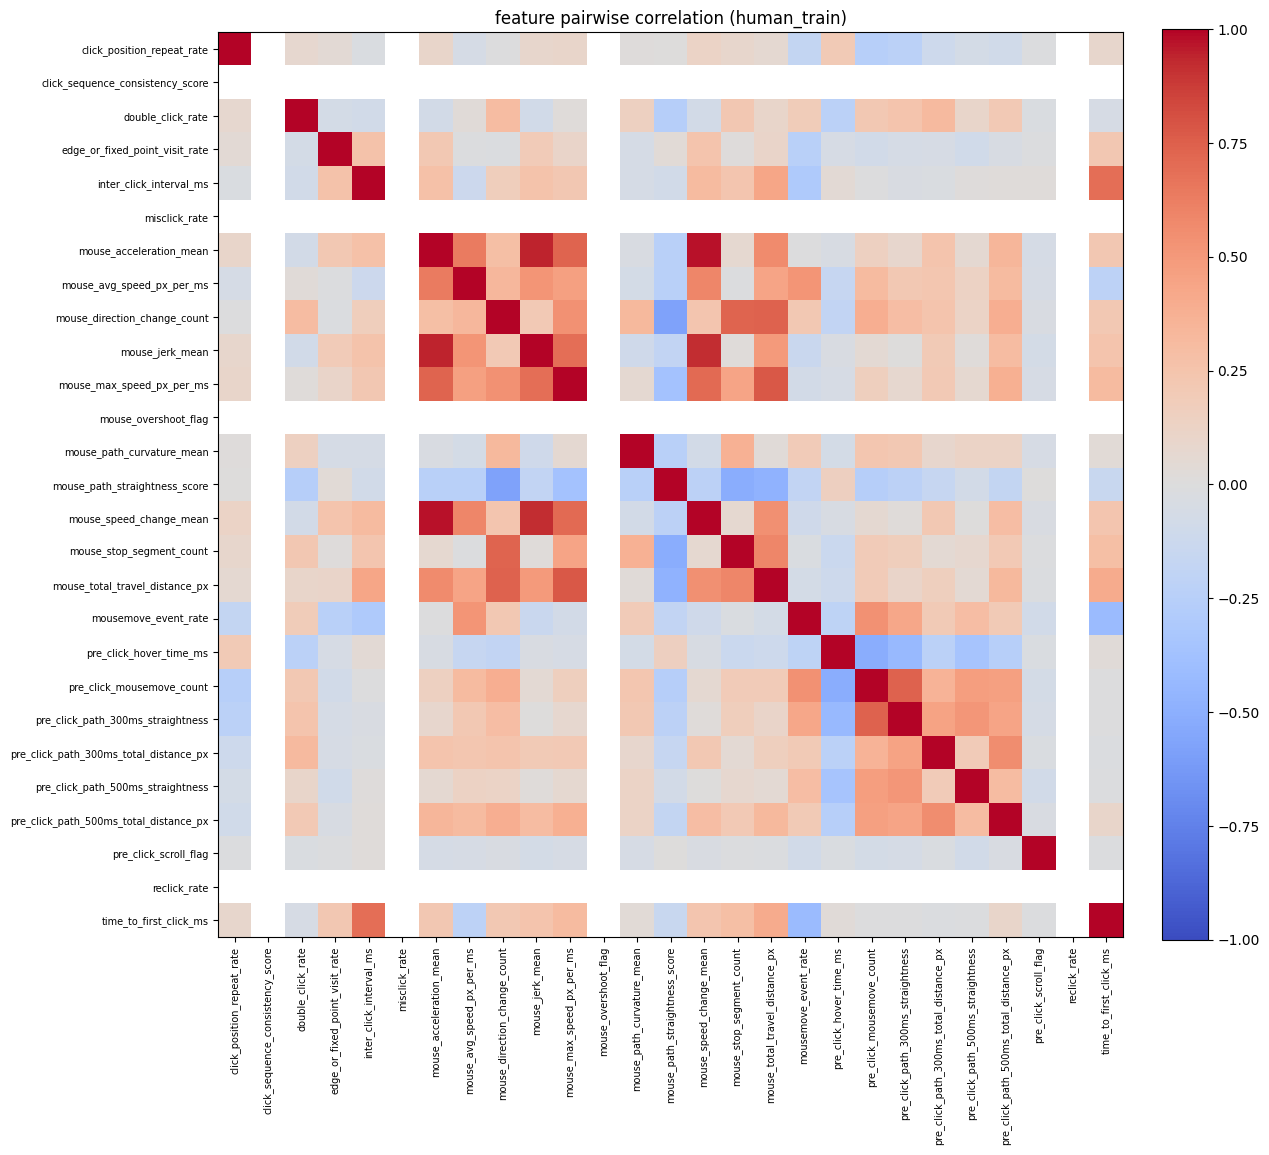

|r| >= 0.9 인 feature pair :
  +0.972  mouse_acceleration_mean  <->  mouse_speed_change_mean
  +0.943  mouse_acceleration_mean  <->  mouse_jerk_mean
  +0.921  mouse_jerk_mean  <->  mouse_speed_change_mean


In [16]:
corr = human_train[feature_names].corr()
side = max(6, min(16, 0.4 * len(feature_names) + 2))
fig, ax = plt.subplots(figsize=(side, side))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=90, fontsize=7)
ax.set_yticklabels(feature_names, fontsize=7)
ax.set_title("feature pairwise correlation (human_train)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
figures["feature_correlation"] = fig
plt.show()

# 강한 상관 (|r| >= 0.9) pair 찾아 출력
high_corr_pairs = []
for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        r = corr.iat[i, j]
        if pd.notna(r) and abs(r) >= 0.9:
            high_corr_pairs.append((feature_names[i], feature_names[j], float(r)))
high_corr_pairs.sort(key=lambda x: -abs(x[2]))
print("|r| >= 0.9 인 feature pair :")
for a, b, r in high_corr_pairs[:20]:
    print(f"  {r:+.3f}  {a}  <->  {b}")
if not high_corr_pairs:
    print("  (없음)")

### 5.8 ✅ feature 별 ALLOW vs BLOCK 분포 (boxplot grid)

feature 마다 valid set 에서 ALLOW (파랑) 와 BLOCK (빨강) 의 box 분포. 두 box 가 거의 겹치지 않으면 분리력 ↑ feature. BLOCK 데이터 없으면 ALLOW box 만.

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20484\3931605637.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([human_valid[fname].dropna().values], labels=["ALLOW"], patch_artist=True)
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20484\3931605637.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([human_valid[fname].dropna().values], labels=["ALLOW"], patch_artist=True)
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20484\3931605637.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([human_valid[fname].dropna().values], labels=["ALLOW"], patch_artist=True)
C:\Users\SSAFY\AppData\Lo

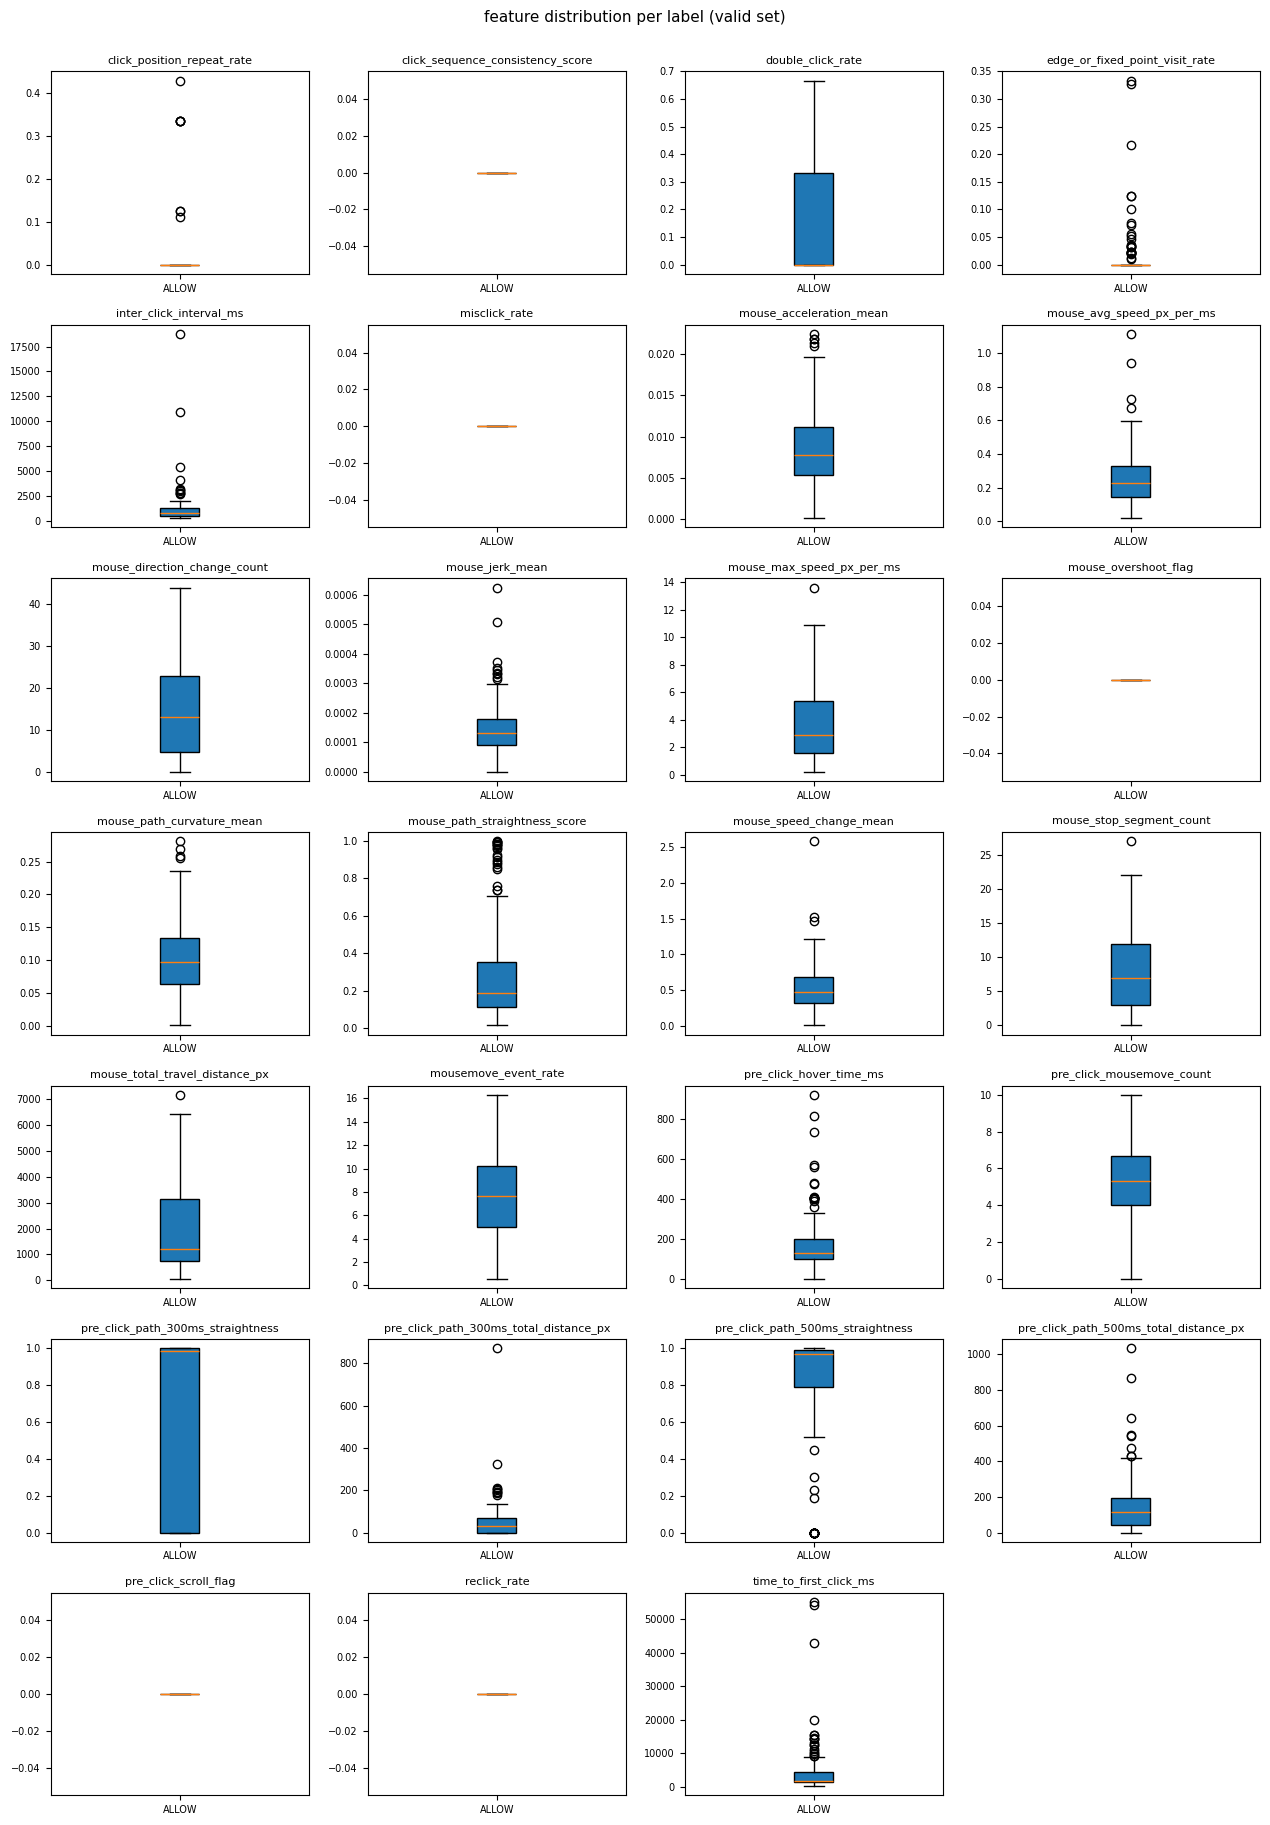

In [17]:
ncols = 4
nrows = (len(feature_names) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 2.6))
axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i, fname in enumerate(feature_names):
    ax = axes_flat[i]
    if has_macro:
        data = [human_valid[fname].dropna().values, macro_valid[fname].dropna().values]
        bp = ax.boxplot(data, labels=["ALLOW", "BLOCK"], patch_artist=True)
        bp["boxes"][0].set_facecolor("steelblue")
        bp["boxes"][0].set_alpha(0.5)
        bp["boxes"][1].set_facecolor("indianred")
        bp["boxes"][1].set_alpha(0.5)
    else:
        ax.boxplot([human_valid[fname].dropna().values], labels=["ALLOW"], patch_artist=True)
    ax.set_title(fname, fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(len(feature_names), len(axes_flat)):
    axes_flat[j].axis("off")

fig.suptitle("feature distribution per label (valid set)", fontsize=11, y=1.0)
plt.tight_layout()
figures["feature_boxplots"] = fig
plt.show()

### 5.9 ✅ Threshold sweep — precision / recall / f1

threshold 를 0.01~0.99 까지 sweep 하면서 precision / recall / f1 변화 그래프. best threshold 는 vertical line. 
(BLOCK 데이터가 없으면 생략)

In [18]:
if has_macro:
    grid = np.arange(args.threshold_step, 1.0, args.threshold_step)
    precs, recs, f1s = [], [], []
    for t in grid:
        y_pred = (y_score >= t).astype(int)
        tp = int(np.sum((y_true == 1) & (y_pred == 1)))
        fp = int(np.sum((y_true == 0) & (y_pred == 1)))
        fn = int(np.sum((y_true == 1) & (y_pred == 0)))
        p = tp / (tp + fp) if (tp + fp) else 0.0
        r = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2.0 * p * r / (p + r) if (p + r) else 0.0
        precs.append(p); recs.append(r); f1s.append(f1)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(grid, precs, label="precision", color="steelblue")
    ax.plot(grid, recs, label="recall", color="indianred")
    ax.plot(grid, f1s, label="f1", color="forestgreen", linewidth=2)
    ax.axvline(
        best_threshold["threshold"], color="grey", linestyle="--",
        label=f"best threshold = {best_threshold['threshold']:.2f}",
    )
    ax.set_xlabel("threshold")
    ax.set_ylabel("metric value")
    ax.set_title("Threshold sweep (valid set)")
    ax.set_ylim(-0.02, 1.02)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    figures["threshold_sweep"] = fig
    plt.show()
else:
    print("(BLOCK 데이터 없음 — threshold sweep 생략)")

(BLOCK 데이터 없음 — threshold sweep 생략)


### 5.10 ✅ ROC curve

False Positive Rate (ALLOW 를 BLOCK 으로 잘못 판정) vs True Positive Rate (BLOCK 을 BLOCK 으로 맞게 판정). 대각선 위쪽으로 멀어질수록 좋은 모델. AUC 가 1 이면 완벽 분리.

In [19]:
if has_macro:
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"AUC = {roc_auc:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", alpha=0.6, label="random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    figures["roc_curve"] = fig
    plt.show()
else:
    print("(BLOCK 데이터 없음 — ROC curve 생략)")

(BLOCK 데이터 없음 — ROC curve 생략)


### 5.11 ✅ Precision-Recall curve

recall 변화에 따른 precision 추이. 우상단에 가까울수록 좋음. class imbalance 가 클 때 ROC 보다 더 신뢰할 수 있는 지표.

In [20]:
if has_macro:
    from sklearn.metrics import precision_recall_curve, average_precision_score
    prec_vals, rec_vals, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    baseline = float(np.mean(y_true))
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(rec_vals, prec_vals, color="darkorange", linewidth=2, label=f"AP = {ap:.4f}")
    ax.axhline(baseline, linestyle="--", color="grey", alpha=0.6, label=f"baseline = {baseline:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curve")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.legend(loc="lower left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    figures["pr_curve"] = fig
    plt.show()
else:
    print("(BLOCK 데이터 없음 — PR curve 생략)")

(BLOCK 데이터 없음 — PR curve 생략)


### 5.12 ✅ Confusion matrix heatmap

5.5 의 텍스트 버전을 heatmap 으로. cell 안에 카운트 표시. 대각선 (TN, TP) 이 진할수록 좋음.

In [21]:
if validation_metrics is not None:
    cm = np.array(validation_metrics["confusion_matrix"])
    fig, ax = plt.subplots(figsize=(5, 4.2))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["pred: ALLOW", "pred: BLOCK"])
    ax.set_yticklabels(["actual: ALLOW", "actual: BLOCK"])
    threshold_color = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, str(cm[i, j]),
                ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > threshold_color else "black",
            )
    ax.set_title(f"Confusion Matrix @ threshold={validation_metrics['threshold']:.2f}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    figures["confusion_matrix"] = fig
    plt.show()
else:
    print("(BLOCK 데이터 없음 — confusion matrix heatmap 생략)")

(BLOCK 데이터 없음 — confusion matrix heatmap 생략)


### 5.13 ✅ k-fold CV — human 분포 안정성 점검

valid 99건만 보는 건 fold 의 우연한 분리에 영향받을 수 있음. ALLOW (human_all) 전체를 5-fold 로 나눠 fold 마다:
1. train_fold 로 IsolationForest 재학습
2. valid_fold 의 macro_probability 분포 (`p05 ~ p95`, mean, std) 측정
3. fold 사이의 편차 확인 → fold 변동이 크면 학습 신호가 불안정한 신호

`center` / `scale` 은 fold 마다 재계산 (cell-54 와 동일 로직, 단 valid_fold 기준).

In [22]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=args.random_state)
fold_summaries = []

for fold_idx, (train_idx, valid_idx) in enumerate(kf.split(human_all), start=1):
    train_fold = human_all.iloc[train_idx].reset_index(drop=True)
    valid_fold = human_all.iloc[valid_idx].reset_index(drop=True)

    fold_model = make_model(args)
    fold_model.fit(train_fold[feature_names])

    fold_raw = np.asarray(fold_model.decision_function(valid_fold[feature_names]), dtype=np.float64)
    fold_center = float(np.quantile(fold_raw, args.contamination))
    fold_scale = float(np.std(fold_raw))
    if not np.isfinite(fold_scale) or fold_scale <= 1e-6:
        fold_scale = 0.05

    fold_prob = decision_scores_to_macro_probability(fold_raw, center=fold_center, scale=fold_scale)
    s = summarize_scores(fold_prob)
    s.update({
        "fold": fold_idx,
        "n_train": len(train_fold),
        "n_valid": len(valid_fold),
        "center": fold_center,
        "scale": fold_scale,
    })
    fold_summaries.append(s)

cv_df = pd.DataFrame(fold_summaries)
cv_df = cv_df[[
    "fold", "n_train", "n_valid",
    "center", "scale",
    "mean", "std", "p05", "p25", "p50", "p75", "p95", "max",
]]
display(cv_df.style.format({c: "{:.4f}" for c in cv_df.columns if c not in ("fold", "n_train", "n_valid")}))

agg = cv_df[["mean", "std", "p95", "max"]].agg(["mean", "std", "min", "max"]).T
agg.columns = ["fold_mean", "fold_std", "fold_min", "fold_max"]
print("\n5-fold 통계 집계 (행=metric, 열=fold 5개 값의 통계):")
print(agg.to_string(float_format=lambda v: f"{v:.4f}"))

# 안정성 판정 — fold 사이 p95 표준편차가 평균 대비 큰 경우 경고
p95_mean = float(cv_df["p95"].mean())
p95_std = float(cv_df["p95"].std(ddof=1))
ratio = p95_std / max(p95_mean, 1e-6)
print(f"\np95 fold 변동 : mean={p95_mean:.4f}, std={p95_std:.4f}, std/mean={ratio:.2%}")
if ratio > 0.20:
    print("  ⚠  fold 사이 변동이 20% 초과 — 학습 신호 불안정 의심 (데이터 부족 / feature scale 차이 / outlier 영향)")
else:
    print("  ✓ fold 변동 안정")


,fold,n_train,n_valid,center,scale,mean,std,p05,p25,p50,p75,p95,max
0,1,560,140,0.0409,0.0410,0.1469,0.1378,0.0312,0.0549,0.0993,0.1756,0.4739,0.6935
1,2,560,140,-0.0143,0.0485,0.1048,0.1246,0.0230,0.0348,0.0650,0.1111,0.3437,0.7494
2,3,560,140,-0.0043,0.0542,0.1331,0.1392,0.0328,0.0452,0.0792,0.1332,0.4301,0.7300
3,4,560,140,-0.0135,0.0507,0.1233,0.1281,0.0257,0.0412,0.0808,0.1474,0.4257,0.6658
4,5,560,140,0.0096,0.0507,0.1580,0.1505,0.0424,0.0638,0.1031,0.1808,0.4188,0.9238



5-fold 통계 집계 (행=metric, 열=fold 5개 값의 통계):
      fold_mean  fold_std  fold_min  fold_max
mean     0.1332    0.0207    0.1048    0.1580
std      0.1360    0.0102    0.1246    0.1505
p95      0.4184    0.0471    0.3437    0.4739
max      0.7525    0.1010    0.6658    0.9238

p95 fold 변동 : mean=0.4184, std=0.0471, std/mean=11.24%
  ✓ fold 변동 안정


## 6. 모델 저장

`services/ai/train/model_joblib/isolation_26_h1_v1_v3/` 에 model.joblib / meta.json / metrics.json 3개 저장. 컨벤션: `hist_gradient_boosting_classifier.ipynb` 와 동일 (model_joblib/<MODEL_NAME>/). 재실행 시 같은 위치에 덮어쓰며, `meta.json` 의 `run_version` 으로 버전 식별.

In [23]:
import joblib

MODEL_NAME = f"isolation_27_h1_v1_{RUN_VERSION}"
MODEL_DIR = AI_ROOT / "train" / "model_joblib" / MODEL_NAME

MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "model.joblib"
meta_path = MODEL_DIR / "meta.json"
metrics_path = MODEL_DIR / "metrics.json"

joblib.dump(model, model_path)

meta = {
    "model_name": MODEL_NAME,
    "run_version": RUN_VERSION,

    "feature_config": {
        "feature_mode": args.feature_mode,
        "features_path": args.features_path,
        "feature_count": len(feature_names),
        "feature_names": feature_names,
        "dropped_features": list(DROP_FEATURES),
    },

    "cleaning_config": {
        "excluded_trial_ids": list(EXCLUDE_TRIAL_IDS),
        "min_numeric_feature_count": MIN_NUMERIC_FEATURE_COUNT,
    },

    "trained_at": datetime.now().isoformat(timespec="seconds"),

    "label_mapping": {
        "ALLOW": 0,
        "BLOCK": 1,
    },

    "dataset": {
        "dataset_dir": args.dataset_dir,
        "valid_ratio": args.valid_ratio,
        "has_macro": bool(has_macro),
        "human_total": int(len(human_all)),
        "human_train": int(len(human_train)),
        "human_valid": int(len(human_valid)),
        "macro_valid": int(len(macro_valid)),
    },

    "model_params": {
        "n_estimators": args.n_estimators,
        "contamination": args.contamination,
        "max_samples": parse_max_samples(args.max_samples),
        "max_features": args.max_features,
        "bootstrap": bool(args.bootstrap),
        "random_state": args.random_state,
    },

    "score_transform": {
        "kind": "iforest_human_as_inlier",
        "score_center": center,
        "score_scale": scale,
    },

    "recommended_threshold": best_threshold,
}

metrics_payload = {
    "run_version": RUN_VERSION,

    "feature_count": len(feature_names),
    "dropped_features": list(DROP_FEATURES),

    "cleaning_config": {
        "excluded_trial_ids": list(EXCLUDE_TRIAL_IDS),
        "min_numeric_feature_count": MIN_NUMERIC_FEATURE_COUNT,
    },

    "model_params": {
        "n_estimators": args.n_estimators,
        "contamination": args.contamination,
        "max_samples": parse_max_samples(args.max_samples),
        "max_features": args.max_features,
        "bootstrap": bool(args.bootstrap),
        "random_state": args.random_state,
    },

    "validation_metrics": validation_metrics,
    "best_threshold": best_threshold,
    "human_valid_score_summary": summarize_scores(human_macro_prob),
}

if has_macro:
    metrics_payload["macro_valid_score_summary"] = summarize_scores(macro_macro_prob)

meta_path.write_text(
    json.dumps(meta, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

metrics_path.write_text(
    json.dumps(metrics_payload, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("saved model:  ", model_path)
print("saved meta:   ", meta_path)
print("saved metrics:", metrics_path)

saved model:   C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\model_joblib\isolation_27_h1_v1_v5_clean_count13_time_strict\model.joblib
saved meta:    C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\model_joblib\isolation_27_h1_v1_v5_clean_count13_time_strict\meta.json
saved metrics: C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\model_joblib\isolation_27_h1_v1_v5_clean_count13_time_strict\metrics.json


## 7. 결과 리포트

이 run 의 핵심 결과를 한 페이지로 정리. 여러 버전을 비교할 때 이 출력을 캡처해서 외부 노트(혹은 cell-13-args 의 VERSION HISTORY 주석)에 누적하세요.

In [24]:
from IPython.display import Markdown, display

# 6.1 핵심 metric 정리 (markdown)
lines = [
    f"## RUN: `{RUN_VERSION}`",
    "",
    "### Dataset",
    f"- dataset_dir: `{args.dataset_dir}`",
    f"- has_macro: **{has_macro}**",
    f"- human_total / train / valid : {len(human_all)} / {len(human_train)} / {len(human_valid)}",
    f"- macro_valid: {len(macro_valid)}",
    f"- excluded_trial_ids: {list(EXCLUDE_TRIAL_IDS) if EXCLUDE_TRIAL_IDS else '(none)'}",
    f"- min_numeric_feature_count: {MIN_NUMERIC_FEATURE_COUNT if MIN_NUMERIC_FEATURE_COUNT is not None else '(none)'}",
    "",
    "### Features",
    f"- feature_count: **{len(feature_names)}**",
    f"- dropped_features: {list(DROP_FEATURES) if DROP_FEATURES else '(none)'}",
    "",
    "### Model",
    f"- n_estimators: {args.n_estimators}, contamination: {args.contamination}, max_samples: {args.max_samples}",
    f"- random_state: {args.random_state}",
    "",
    "### Threshold",
    f"- threshold: **{float(best_threshold['threshold']):.4f}**",
]
if best_threshold.get("strategy"):
    lines.append(f"- strategy: {best_threshold['strategy']}")
for key in ("precision", "recall", "f1"):
    v = best_threshold.get(key)
    if v is not None:
        lines.append(f"- {key}: {float(v):.4f}")

lines.extend(["", "### Validation Metrics"])
if validation_metrics is None:
    lines.append("- (no BLOCK data — skipped)")
else:
    for key in ("accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"):
        lines.append(f"- {key}: **{float(validation_metrics[key]):.4f}**")

display(Markdown("\n".join(lines)))

# 6.2 전체 요약 JSON
summary = {
    "run_version": RUN_VERSION,
    "dropped_features": list(DROP_FEATURES),
    "feature_count": len(feature_names),
    "feature_names": feature_names,
    "dataset": {
        "dataset_dir": args.dataset_dir,
        "has_macro": bool(has_macro),
        "human_total": int(len(human_all)),
        "human_train": int(len(human_train)),
        "human_valid": int(len(human_valid)),
        "macro_valid": int(len(macro_valid)),
    },
    "best_threshold": best_threshold,
    "validation_metrics": validation_metrics,
    "human_valid_score_summary": summarize_scores(human_macro_prob),
}
if has_macro:
    summary["macro_valid_score_summary"] = summarize_scores(macro_macro_prob)
print(json.dumps(summary, ensure_ascii=False, indent=2))


## RUN: `v5_clean_count13_time_strict`

### Dataset
- dataset_dir: `C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data\data_h1_v1_allow`
- has_macro: **False**
- human_total / train / valid : 700 / 560 / 140
- macro_valid: 0
- excluded_trial_ids: [339, 369, 383, 721, 750]
- min_numeric_feature_count: 14

### Features
- feature_count: **27**
- dropped_features: (none)

### Model
- n_estimators: 300, contamination: 0.03, max_samples: auto
- random_state: 42

### Threshold
- threshold: **0.5000**
- strategy: quantile_of_human_only

### Validation Metrics
- (no BLOCK data — skipped)

{
  "run_version": "v5_clean_count13_time_strict",
  "dropped_features": [],
  "feature_count": 27,
  "feature_names": [
    "click_position_repeat_rate",
    "click_sequence_consistency_score",
    "double_click_rate",
    "edge_or_fixed_point_visit_rate",
    "inter_click_interval_ms",
    "misclick_rate",
    "mouse_acceleration_mean",
    "mouse_avg_speed_px_per_ms",
    "mouse_direction_change_count",
    "mouse_jerk_mean",
    "mouse_max_speed_px_per_ms",
    "mouse_overshoot_flag",
    "mouse_path_curvature_mean",
    "mouse_path_straightness_score",
    "mouse_speed_change_mean",
    "mouse_stop_segment_count",
    "mouse_total_travel_distance_px",
    "mousemove_event_rate",
    "pre_click_hover_time_ms",
    "pre_click_mousemove_count",
    "pre_click_path_300ms_straightness",
    "pre_click_path_300ms_total_distance_px",
    "pre_click_path_500ms_straightness",
    "pre_click_path_500ms_total_distance_px",
    "pre_click_scroll_flag",
    "reclick_rate",
    "time_to_first_c

## 8. 외부 데이터 테스트 (data_m1_v2_block)

학습된 모델을 `data_m1_v2_block` BLOCK trial에 적용해 외부 test 성능을 확인합니다.

학습/검증 시 결정된 `feature_names`, `score_transform(center/scale)`, `best_threshold`를 그대로 재사용합니다.

### 8.1 ✅ 데이터 로드 + macro_probability 계산

c1_macro 의 trial 들을 동일한 feature 추출 파이프라인 (`load_trials_by_label`) 으로 로드 후 학습된 모델의 `decision_function` → `macro_probability` 변환.

In [25]:
TEST_DATASET_NAME = "data_m1_v2_block"
TEST_DIR = AI_ROOT / "data" / TEST_DATASET_NAME

test_trials_by_label = load_trials_by_label(TEST_DIR, feature_names, args.glob)

print(f"{TEST_DATASET_NAME} label 분포:", {
    k: len(v) for k, v in test_trials_by_label.items()
})

test_block_df = pd.DataFrame()

for candidate_label in ("BLOCK", "block", "macro"):
    candidate_df = test_trials_by_label.get(candidate_label)

    if candidate_df is not None and not candidate_df.empty:
        test_block_df = candidate_df.reset_index(drop=True)
        break

if test_block_df.empty:
    raise RuntimeError(f"no BLOCK-like trials found in {TEST_DIR}")

test_raw_scores = np.asarray(
    model.decision_function(test_block_df[feature_names]),
    dtype=np.float64,
)

test_macro_prob = decision_scores_to_macro_probability(
    test_raw_scores,
    center=center,
    scale=scale,
)

print(f"\nTEST DATASET            : {TEST_DATASET_NAME}")
print(f"test BLOCK trial 수      : {len(test_block_df)}")
print("macro_probability 분포 :")
print(json.dumps(summarize_scores(test_macro_prob), indent=2))

data_m1_v2_block label 분포: {'BLOCK': 460}

TEST DATASET            : data_m1_v2_block
test BLOCK trial 수      : 460
macro_probability 분포 :
{
  "count": 460,
  "min": 0.029155608708784902,
  "p05": 0.334507963299157,
  "p25": 0.3876700464621398,
  "p50": 0.4902709797454192,
  "p75": 0.7749139296473564,
  "p95": 0.7795939598771767,
  "max": 0.8730758282079847,
  "mean": 0.5472562299455256,
  "std": 0.18625563212122523
}


### 8.2 ✅ BLOCK 검출률 (recall) + 히스토그램

학습 시 결정된 `best_threshold` 를 그대로 적용해 c1_macro 의 몇 % 를 BLOCK 으로 잡는지 측정. recall 이 낮으면 h1 도메인에서 학습한 모델이 c1 매크로 패턴을 못 잡는다는 의미.

TEST DATASET             : data_m1_v2_block
threshold (학습 시 결정)  : 0.5000
test BLOCK 전체          : 460
BLOCK 으로 분류된 건수    : 222
recall (BLOCK 검출률)    : 0.4826 (48.26%)


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20484\1190628535.py:39: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20484\1190628535.py:39: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


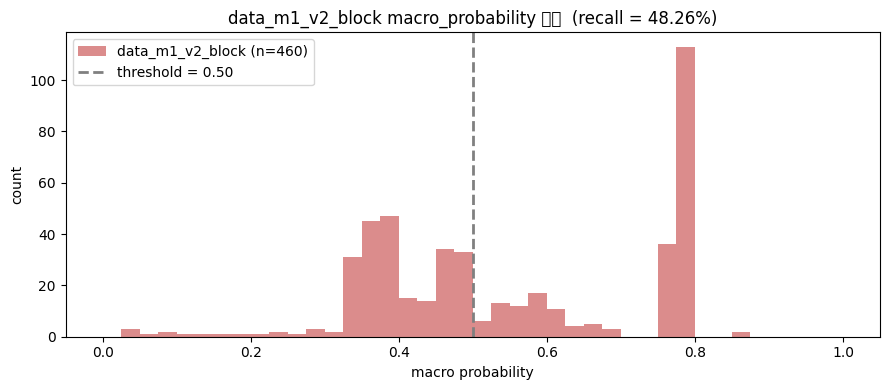

In [26]:
test_threshold = float(best_threshold["threshold"])

predicted_block = (test_macro_prob >= test_threshold).astype(int)

n_total = len(test_block_df)
n_caught = int(predicted_block.sum())
recall = n_caught / n_total if n_total else 0.0

print(f"TEST DATASET             : {TEST_DATASET_NAME}")
print(f"threshold (학습 시 결정)  : {test_threshold:.4f}")
print(f"test BLOCK 전체          : {n_total}")
print(f"BLOCK 으로 분류된 건수    : {n_caught}")
print(f"recall (BLOCK 검출률)    : {recall:.4f} ({recall:.2%})")

fig, ax = plt.subplots(figsize=(9, 4))

bins = np.linspace(0.0, 1.0, 41)

ax.hist(
    test_macro_prob,
    bins=bins,
    alpha=0.7,
    color="indianred",
    label=f"{TEST_DATASET_NAME} (n={n_total})",
)

ax.axvline(
    test_threshold,
    color="grey",
    linestyle="--",
    linewidth=2,
    label=f"threshold = {test_threshold:.2f}",
)

ax.set_xlabel("macro probability")
ax.set_ylabel("count")
ax.set_title(f"{TEST_DATASET_NAME} macro_probability 분포  (recall = {recall:.2%})")
ax.legend()
plt.tight_layout()
plt.show()